## 0. Install Dependencies (if needed)

Run this cell if you encounter import errors:


In [16]:
# Install optional dependencies if needed
# Uncomment and run if statsmodels is not installed:
# !pip install statsmodels


# Model Upgrade Impact Analysis in WildChat

**Purpose:** Analyze the effect of model upgrades on user utilization, engagement, and satisfaction.

**Context:** Previous analyses revealed that:
- Word count (proxy for task complexity) dominates engagement prediction
- Semantic diversity correlates with utilization (r = 0.43)
- Users prioritize efficiency—"does the AI get the job done?"

If engagement is driven by AI capability, then **model upgrades should produce measurable improvements** in user behavior. This notebook tests that hypothesis.

**Dataset:** WildChat preprocessed conversation data with user IDs

---

## Hypotheses

| ID | Hypothesis | Prediction | Metric |
|----|------------|------------|--------|
| H1 | Model upgrades attract more users | New user count increases post-upgrade | daily_new_users |
| H2 | Model upgrades increase utilization | Return rate increases post-upgrade | return_rate_60d |
| H3 | Model upgrades increase diversity | Topic/intent diversity increases | semantic_spread, intent_entropy |
| H4 | Model upgrades increase conversation depth | Turns per conversation increases | mean_turns_per_conv |
| H5 | Model upgrades increase satisfaction | Longer sessions, more follow-ups | session_length, follow_up_rate |

---

## Contents

1. Setup and Dependencies
2. Data Loading and Model Version Identification
3. Define Model Upgrade Events
4. Compute Daily Metrics
5. Weekly Cohort Return Rates
6. H1: Model Upgrades Attract More Users
7. H2: Model Upgrades Increase Utilization (Return Rate)
8. H3: Model Upgrades Increase Diversity
9. H4: Model Upgrades Increase Conversation Depth
10. H5: Model Upgrades Increase Satisfaction (Session Metrics)
11. Controlling for Confounds
12. Model-Specific Analysis
13. Summary and Conclusions


In [17]:
# ============================================================
# Setup & Dependencies
# ============================================================

import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import mannwhitneyu
from datetime import datetime, timedelta
import glob
import warnings
warnings.filterwarnings('ignore')

# For interrupted time series analysis (optional - install with: pip install statsmodels)
try:
    import statsmodels.api as sm
    from statsmodels.regression.linear_model import OLS
    from statsmodels.tsa.seasonal import seasonal_decompose
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False
    print("Warning: statsmodels not installed. H2 (ITS analysis) and seasonal decomposition will be skipped.")
    print("Install with: pip install statsmodels")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Phronos brand colors
BRAND = {
    'paper': '#F2F0E9',
    'ink': '#1A1A1A',
    'gold': '#B08D55',
    'alert': '#CC5544',
    'success': '#44AA77',
}

def apply_phronos_style(ax):
    ax.set_facecolor(BRAND['paper'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(BRAND['ink'])
    ax.spines['bottom'].set_color(BRAND['ink'])
    ax.tick_params(colors=BRAND['ink'])
    ax.grid(True, alpha=0.3, color=BRAND['ink'], linewidth=0.5)

def save_figure(fig, name, dpi=150):
    import os
    output_dir = '../outputs/figures'
    os.makedirs(output_dir, exist_ok=True)
    filepath = f'{output_dir}/{name}.png'
    fig.savefig(filepath, dpi=dpi, bbox_inches='tight', facecolor=BRAND['paper'])
    print(f"Saved: {filepath}")

print("Setup complete.")


Install with: pip install statsmodels
Setup complete.


## 2. Data Loading and Model Version Identification


In [18]:
# ============================================================
# DATA LOADING AND MODEL VERSION EXTRACTION
# ============================================================

print("="*70)
print("DATA LOADING AND MODEL VERSION EXTRACTION")
print("="*70)

# Load preprocessed data using lazy loading for efficiency
parquet_files = glob.glob('../outputs/data/protest_with_users/*.parquet')
if len(parquet_files) == 0:
    raise FileNotFoundError("No parquet files found in ../outputs/data/protest_with_users/")

print(f"Found {len(parquet_files)} parquet files")

# Use lazy loading for better memory efficiency
df = pl.scan_parquet('../outputs/data/protest_with_users/*.parquet').collect()
print(f"Loaded {len(df):,} conversations")

# Extract model version from data
# WildChat includes 'model' column with version info
print(f"\nModel versions in data:")
model_counts = df.group_by('model').len().sort('len', descending=True)
for row in model_counts.head(20).iter_rows(named=True):
    print(f"  {row['model']}: {row['len']:,} ({100*row['len']/len(df):.1f}%)")

# Standardize model versions to major releases
def standardize_model_version(model_str):
    """
    Map specific model strings to major version categories.
    Adjust based on actual values in your data.
    """
    if model_str is None:
        return 'unknown'
    model_str = str(model_str).lower()
    
    # GPT models
    if 'gpt-4-turbo' in model_str or 'gpt-4-1106' in model_str or 'gpt-4-0125' in model_str:
        return 'gpt-4-turbo'
    elif 'gpt-4-32k' in model_str:
        return 'gpt-4-32k'
    elif 'gpt-4' in model_str:
        return 'gpt-4'
    elif 'gpt-3.5-turbo-16k' in model_str:
        return 'gpt-3.5-turbo-16k'
    elif 'gpt-3.5' in model_str:
        return 'gpt-3.5-turbo'
    
    # Claude models
    elif 'claude-3-opus' in model_str:
        return 'claude-3-opus'
    elif 'claude-3-sonnet' in model_str:
        return 'claude-3-sonnet'
    elif 'claude-3-haiku' in model_str:
        return 'claude-3-haiku'
    elif 'claude-2' in model_str:
        return 'claude-2'
    elif 'claude' in model_str:
        return 'claude-1'
    
    # Llama models
    elif 'llama-2-70b' in model_str:
        return 'llama-2-70b'
    elif 'llama-2' in model_str:
        return 'llama-2'
    elif 'llama' in model_str:
        return 'llama'
    
    # Mixtral
    elif 'mixtral' in model_str:
        return 'mixtral'
    
    else:
        return 'other'

# Apply standardization
df = df.with_columns([
    pl.col('model').map_elements(standardize_model_version, return_dtype=pl.Utf8)
        .alias('model_family')
])

print(f"\nStandardized model families:")
family_counts = df.group_by('model_family').len().sort('len', descending=True)
for row in family_counts.iter_rows(named=True):
    print(f"  {row['model_family']}: {row['len']:,} ({100*row['len']/len(df):.1f}%)")

# Ensure timestamp is datetime
if 'timestamp' not in df.columns:
    raise ValueError("'timestamp' column not found in data")
    
if df['timestamp'].dtype != pl.Datetime:
    df = df.with_columns([
        pl.col('timestamp').str.strptime(pl.Datetime, format='%Y-%m-%d %H:%M:%S', strict=False)
    ])

print(f"\nData date range: {df['timestamp'].min()} to {df['timestamp'].max()}")


DATA LOADING AND MODEL VERSION EXTRACTION
Found 127 parquet files
Loaded 4,743,336 conversations

Model versions in data:
  gpt-4o-2024-08-06: 1,541,292 (32.5%)
  gpt-4.1-mini-2025-04-14: 945,660 (19.9%)
  gpt-4o-mini-2024-07-18: 816,019 (17.2%)
  gpt-3.5-turbo-0613: 433,089 (9.1%)
  gpt-3.5-turbo-0301: 236,545 (5.0%)
  gpt-3.5-turbo-0125: 184,057 (3.9%)
  gpt-4o-2024-05-13: 129,176 (2.7%)
  gpt-4-1106-preview: 121,159 (2.6%)
  gpt-4-0125-preview: 82,789 (1.7%)
  gpt-4-0314: 64,217 (1.4%)
  o1-preview-2024-09-12: 61,525 (1.3%)
  o1-mini-2024-09-12: 61,396 (1.3%)
  gpt-4o-2024-11-20: 38,193 (0.8%)
  gpt-4-turbo-2024-04-09: 28,217 (0.6%)
  gpt-4-0613: 2 (0.0%)

Standardized model families:
  gpt-4: 3,534,559 (74.5%)
  gpt-3.5-turbo: 853,691 (18.0%)
  gpt-4-turbo: 232,165 (4.9%)
  other: 122,921 (2.6%)

Data date range: 2023-04-09 00:01:06 to 2025-07-31 23:59:01


## 3. Define Model Upgrade Events


In [19]:
# ============================================================
# DEFINE MODEL UPGRADE EVENTS
# ============================================================

print("="*70)
print("MODEL UPGRADE EVENT IDENTIFICATION")
print("="*70)

# Known major model release dates (approximate availability in WildChat)
# Adjust based on when models first appear in YOUR data
MODEL_EVENTS = [
    {
        'name': 'GPT-4 Release',
        'date': datetime(2023, 3, 14),
        'description': 'GPT-4 API general availability',
        'model_family': 'gpt-4',
    },
    {
        'name': 'GPT-3.5-16k',
        'date': datetime(2023, 6, 13),
        'description': 'Extended context window',
        'model_family': 'gpt-3.5-turbo-16k',
    },
    {
        'name': 'Claude 2',
        'date': datetime(2023, 7, 11),
        'description': 'Claude 2 release',
        'model_family': 'claude-2',
    },
    {
        'name': 'GPT-4-Turbo',
        'date': datetime(2023, 11, 6),
        'description': 'GPT-4 Turbo with 128k context',
        'model_family': 'gpt-4-turbo',
    },
    {
        'name': 'Claude 3',
        'date': datetime(2024, 3, 4),
        'description': 'Claude 3 family release',
        'model_family': 'claude-3-opus',
    },
]

# Verify events are in data range
data_start = df['timestamp'].min()
data_end = df['timestamp'].max()
print(f"Data range: {data_start} to {data_end}")

# Convert event dates to datetime for comparison
valid_events = []
for e in MODEL_EVENTS:
    event_date = e['date']
    if isinstance(event_date, datetime):
        # Compare datetime with datetime
        if data_start <= event_date <= data_end:
            valid_events.append(e)
    else:
        # If it's a date, convert to datetime
        event_datetime = datetime.combine(event_date, datetime.min.time())
        if data_start <= event_datetime <= data_end:
            valid_events.append(e)
print(f"\nEvents within data range: {len(valid_events)}")
for event in valid_events:
    print(f"  {event['date'].strftime('%Y-%m-%d')}: {event['name']}")

# Identify when models first appear in data (data-driven)
model_first_seen = df.group_by('model_family').agg([
    pl.col('timestamp').min().alias('first_seen'),
    pl.col('timestamp').max().alias('last_seen'),
    pl.len().alias('n_conversations'),
]).sort('first_seen')

print(f"\nModel families by first appearance:")
for row in model_first_seen.iter_rows(named=True):
    print(f"  {row['first_seen'].strftime('%Y-%m-%d')}: {row['model_family']} "
          f"(n={row['n_conversations']:,})")


MODEL UPGRADE EVENT IDENTIFICATION
Data range: 2023-04-09 00:01:06 to 2025-07-31 23:59:01

Events within data range: 4
  2023-06-13: GPT-3.5-16k
  2023-07-11: Claude 2
  2023-11-06: GPT-4-Turbo
  2024-03-04: Claude 3

Model families by first appearance:
  2023-04-09: gpt-4 (n=3,534,559)
  2023-04-09: gpt-3.5-turbo (n=853,691)
  2023-11-06: gpt-4-turbo (n=232,165)
  2024-09-12: other (n=122,921)


## 4. Compute Daily Metrics


In [20]:
# ============================================================
# COMPUTE DAILY METRICS TIME SERIES
# ============================================================

print("="*70)
print("COMPUTING DAILY METRICS")
print("="*70)

# Add date column
df = df.with_columns([
    pl.col('timestamp').dt.date().alias('date')
])

# Daily aggregates
daily_metrics = df.group_by('date').agg([
    # Volume metrics
    pl.len().alias('n_conversations'),
    pl.col('user_id').n_unique().alias('n_unique_users'),
    pl.col('n_turns').sum().alias('total_turns'),
    pl.col('n_turns').mean().alias('mean_turns'),
    pl.col('n_turns').median().alias('median_turns'),
    
    # Model distribution
    pl.col('model_family').n_unique().alias('n_models_used'),
    
    # Content metrics (if available)
    # pl.col('word_count').mean().alias('mean_word_count'),
]).sort('date')

# New users per day
user_first_date = df.group_by('user_id').agg([
    pl.col('timestamp').min().dt.date().alias('first_date')
])

new_users_daily = user_first_date.group_by('first_date').len().rename({
    'first_date': 'date', 
    'len': 'n_new_users'
})

daily_metrics = daily_metrics.join(new_users_daily, on='date', how='left')
daily_metrics = daily_metrics.with_columns([
    pl.col('n_new_users').fill_null(0)
])

# Compute return rate (requires user-level follow-up tracking)
# For each day, what % of new users return within 60 days?
# This is computationally expensive - compute for weekly cohorts instead

print(f"Daily metrics computed: {len(daily_metrics)} days")
print(f"  Date range: {daily_metrics['date'].min()} to {daily_metrics['date'].max()}")
print(f"  Mean conversations/day: {daily_metrics['n_conversations'].mean():,.0f}")
print(f"  Mean new users/day: {daily_metrics['n_new_users'].mean():,.0f}")


COMPUTING DAILY METRICS
Daily metrics computed: 809 days
  Date range: 2023-04-09 to 2025-07-31
  Mean conversations/day: 5,863
  Mean new users/day: 3,044


## 5. Weekly Cohort Return Rates


In [21]:
# ============================================================
# WEEKLY COHORT RETURN RATE ANALYSIS
# ============================================================

print("="*70)
print("WEEKLY COHORT RETURN RATE ANALYSIS")
print("="*70)

# Assign users to weekly cohorts based on first conversation
user_cohorts = df.group_by('user_id').agg([
    pl.col('timestamp').min().alias('first_conv'),
    pl.col('timestamp').max().alias('last_conv'),
    pl.len().alias('n_conversations'),
]).with_columns([
    # Week of first conversation
    pl.col('first_conv').dt.truncate('1w').alias('cohort_week'),
    # Did user return? (more than 1 conversation)
    (pl.col('n_conversations') > 1).alias('returned'),
    # Return within 60 days?
    ((pl.col('last_conv') - pl.col('first_conv')).dt.total_seconds() / 86400.0 <= 60).alias('returned_60d'),
])

# Aggregate by cohort week
cohort_metrics = user_cohorts.group_by('cohort_week').agg([
    pl.len().alias('cohort_size'),
    pl.col('returned').sum().alias('n_returned'),
    pl.col('returned').mean().alias('return_rate'),
    pl.col('n_conversations').mean().alias('mean_conversations'),
    pl.col('n_conversations').median().alias('median_conversations'),
]).sort('cohort_week')

# Filter to cohorts with enough follow-up time
cutoff_date = df['timestamp'].max() - timedelta(days=60)
cohort_metrics = cohort_metrics.filter(
    pl.col('cohort_week') < cutoff_date
)

print(f"Weekly cohorts with 60d follow-up: {len(cohort_metrics)}")
print(f"  Mean cohort size: {cohort_metrics['cohort_size'].mean():,.0f}")
print(f"  Mean return rate: {cohort_metrics['return_rate'].mean():.1%}")


WEEKLY COHORT RETURN RATE ANALYSIS
Weekly cohorts with 60d follow-up: 110
  Mean cohort size: 21,381
  Mean return rate: 33.6%


## 6. H1: Model Upgrades Attract More Users


H1: MODEL UPGRADES → MORE USERS
Saved: ../outputs/figures/h1_new_users_over_time.png


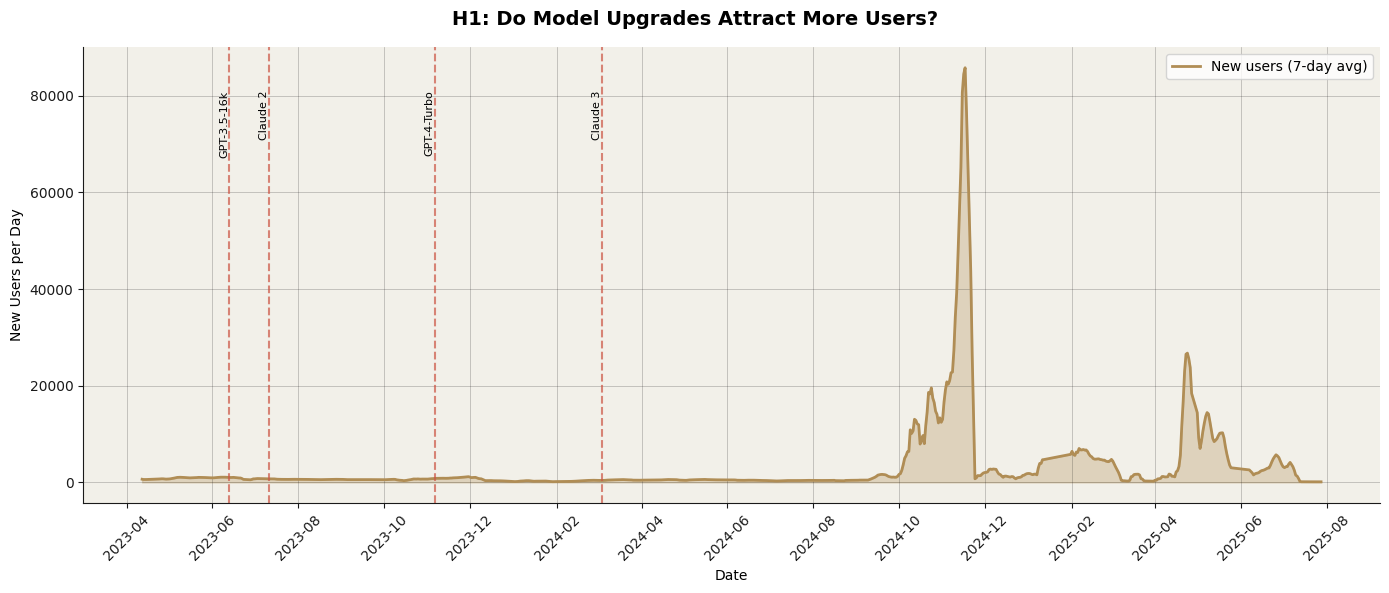


Pre/Post Upgrade Comparison (New Users):
------------------------------------------------------------
GPT-3.5-16k:
  Pre:  1,007 users/day
  Post: 803 users/day (-20.3%)
  p = 0.0001 ***
Claude 2:
  Pre:  813 users/day
  Post: 667 users/day (-17.9%)
  p = 0.0001 ***
GPT-4-Turbo:
  Pre:  613 users/day
  Post: 955 users/day (+55.8%)
  p = 0.0000 ***
Claude 3:
  Pre:  312 users/day
  Post: 513 users/day (+64.8%)
  p = 0.0000 ***


In [22]:
# ============================================================
# H1: MODEL UPGRADES ATTRACT MORE USERS
# ============================================================

print("="*70)
print("H1: MODEL UPGRADES → MORE USERS")
print("="*70)

# Visualization: Daily new users with upgrade events marked
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('H1: Do Model Upgrades Attract More Users?', fontsize=14, fontweight='bold')

# Plot daily new users (7-day rolling average for smoothing)
dates = pd.to_datetime(daily_metrics['date'].to_list())
new_users = daily_metrics['n_new_users'].to_numpy()
rolling_new_users = pd.Series(new_users).rolling(7, center=True).mean()

ax.plot(dates, rolling_new_users, color=BRAND['gold'], linewidth=2, label='New users (7-day avg)')
ax.fill_between(dates, 0, rolling_new_users, alpha=0.3, color=BRAND['gold'])

# Mark upgrade events
for event in valid_events:
    ax.axvline(x=event['date'], color=BRAND['alert'], linestyle='--', alpha=0.7)
    ax.annotate(event['name'], xy=(event['date'], ax.get_ylim()[1]*0.9),
                rotation=90, fontsize=8, ha='right', va='top')

ax.set_xlabel('Date')
ax.set_ylabel('New Users per Day')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'h1_new_users_over_time')
plt.show()

# Statistical test: Compare pre vs post each upgrade
print("\nPre/Post Upgrade Comparison (New Users):")
print("-" * 60)

WINDOW_DAYS = 30  # Compare 30 days before vs 30 days after

for event in valid_events:
    pre_start = event['date'] - timedelta(days=WINDOW_DAYS)
    pre_end = event['date']
    post_start = event['date']
    post_end = event['date'] + timedelta(days=WINDOW_DAYS)
    
    # Convert dates to same type for comparison
    pre_start_date = pre_start.date() if isinstance(pre_start, datetime) else pre_start
    pre_end_date = pre_end.date() if isinstance(pre_end, datetime) else pre_end
    post_start_date = post_start.date() if isinstance(post_start, datetime) else post_start
    post_end_date = post_end.date() if isinstance(post_end, datetime) else post_end
    
    pre_data = daily_metrics.filter(
        (pl.col('date') >= pre_start_date) & (pl.col('date') < pre_end_date)
    )['n_new_users'].to_numpy()
    
    post_data = daily_metrics.filter(
        (pl.col('date') >= post_start_date) & (pl.col('date') < post_end_date)
    )['n_new_users'].to_numpy()
    
    if len(pre_data) > 5 and len(post_data) > 5:
        pre_mean = pre_data.mean()
        post_mean = post_data.mean()
        change_pct = (post_mean - pre_mean) / pre_mean * 100 if pre_mean > 0 else 0
        
        stat, p = mannwhitneyu(pre_data, post_data, alternative='two-sided')
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        
        print(f"{event['name']}:")
        print(f"  Pre:  {pre_mean:,.0f} users/day")
        print(f"  Post: {post_mean:,.0f} users/day ({change_pct:+.1f}%)")
        print(f"  p = {p:.4f} {sig}")


## 7. H2: Model Upgrades Increase Utilization (Return Rate)


H2: MODEL UPGRADES → HIGHER RETURN RATE
Saved: ../outputs/figures/h2_return_rate_over_time.png


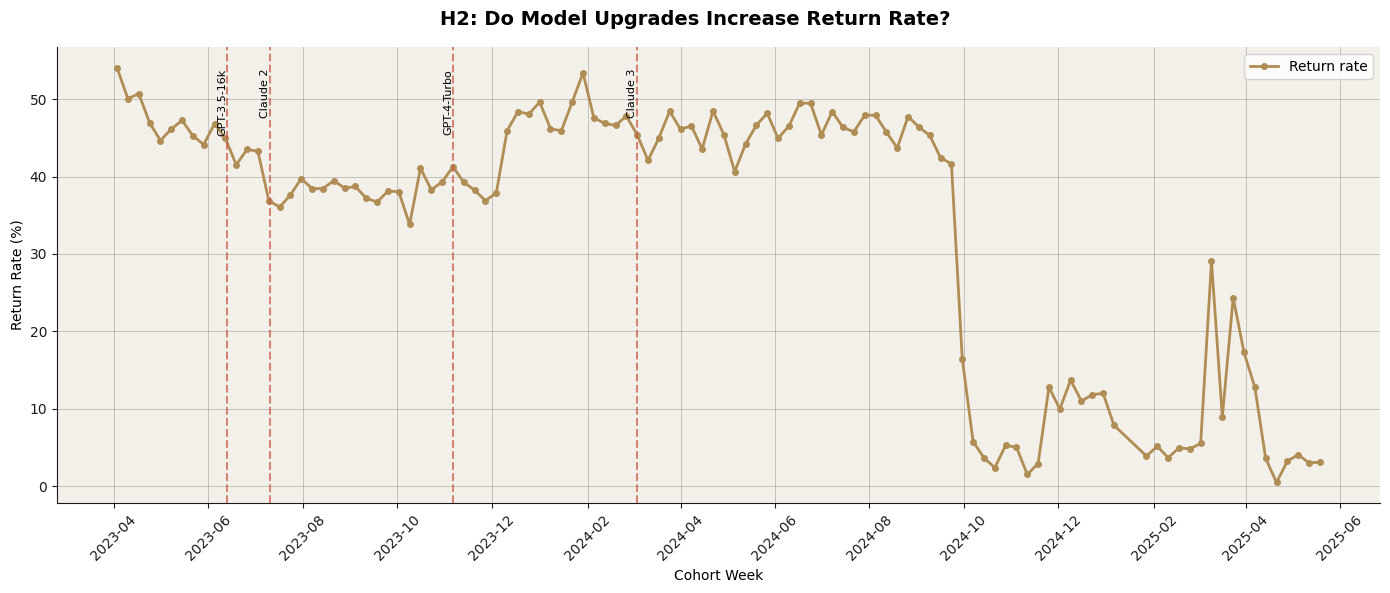


Interrupted Time Series Analysis:
------------------------------------------------------------
Skipped: statsmodels not installed. Install with: pip install statsmodels


In [23]:
# ============================================================
# H2: MODEL UPGRADES → HIGHER RETURN RATE
# ============================================================

print("="*70)
print("H2: MODEL UPGRADES → HIGHER RETURN RATE")
print("="*70)

# Visualization: Return rate over time
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('H2: Do Model Upgrades Increase Return Rate?', fontsize=14, fontweight='bold')

cohort_dates = pd.to_datetime(cohort_metrics['cohort_week'].to_list())
return_rates = cohort_metrics['return_rate'].to_numpy()

ax.plot(cohort_dates, return_rates * 100, color=BRAND['gold'], linewidth=2, 
        marker='o', markersize=4, label='Return rate')

# Mark upgrade events
for event in valid_events:
    ax.axvline(x=event['date'], color=BRAND['alert'], linestyle='--', alpha=0.7)
    ax.annotate(event['name'], xy=(event['date'], ax.get_ylim()[1]*0.95),
                rotation=90, fontsize=8, ha='right', va='top')

ax.set_xlabel('Cohort Week')
ax.set_ylabel('Return Rate (%)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'h2_return_rate_over_time')
plt.show()

# Interrupted time series analysis
if STATSMODELS_AVAILABLE:
    print("\nInterrupted Time Series Analysis:")
    print("-" * 60)
    
    # For each event, fit: Y = β0 + β1*time + β2*post + β3*time_since_event + ε
    for event in valid_events[:3]:  # Analyze first 3 events
        event_date = event['date']
        
        # Prepare data
        analysis_data = cohort_metrics.with_columns([
            (pl.col('cohort_week') >= event_date).cast(pl.Int32).alias('post'),
            ((pl.col('cohort_week') - cohort_metrics['cohort_week'].min()).dt.total_seconds() / 86400.0).alias('time'),
        ]).with_columns([
            (pl.col('time') * pl.col('post')).alias('time_since_event')
        ])
        
        X = analysis_data.select(['time', 'post', 'time_since_event']).to_numpy()
        X = sm.add_constant(X)
        y = analysis_data['return_rate'].to_numpy()
        
        model = OLS(y, X).fit()
        
        print(f"\n{event['name']}:")
        print(f"  Immediate effect (post): {model.params[2]:.4f} "
              f"({'+'if model.params[2]>0 else ''}{model.params[2]*100:.1f}pp)")
        print(f"  Trend change (time_since): {model.params[3]*7:.6f}/week")
        print(f"  p-values: post={model.pvalues[2]:.4f}, trend={model.pvalues[3]:.4f}")
else:
    print("\nInterrupted Time Series Analysis:")
    print("-" * 60)
    print("Skipped: statsmodels not installed. Install with: pip install statsmodels")


## 8. H3: Model Upgrades Increase Diversity


H3: MODEL UPGRADES → GREATER TOPIC DIVERSITY
Saved: ../outputs/figures/h3_diversity_over_time.png


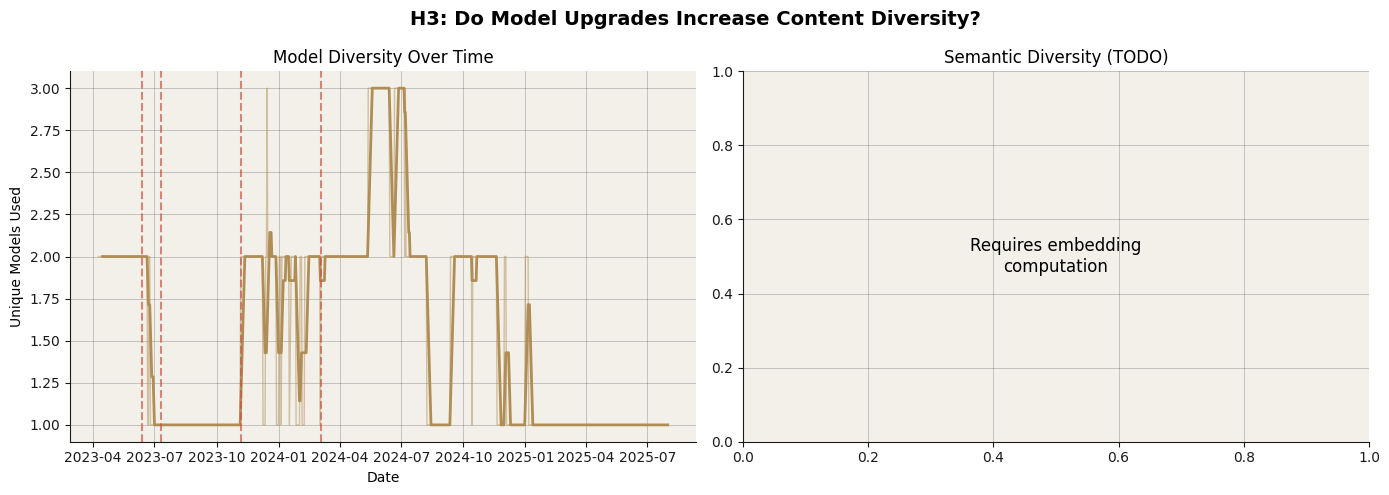

In [24]:
# ============================================================
# H3: MODEL UPGRADES → GREATER TOPIC DIVERSITY
# ============================================================

print("="*70)
print("H3: MODEL UPGRADES → GREATER TOPIC DIVERSITY")
print("="*70)

# If embeddings are available, compute daily semantic diversity
# Otherwise, use intent diversity as proxy

# Option A: Intent entropy per day (if intent labels available)
if 'intent' in df.columns:
    from collections import Counter
    import math
    
    def compute_entropy(values):
        """Compute entropy of a list of values."""
        if not values or len(values) == 0:
            return 0.0
        counts = Counter(values)
        total = sum(counts.values())
        if total == 0:
            return 0.0
        probs = [c/total for c in counts.values()]
        return -sum(p * math.log2(p) for p in probs if p > 0)
    
    # Compute entropy per day
    # Group by date and compute entropy on intent values
    # Note: map_elements is acceptable here since we're grouping by date (manageable number of groups)
    daily_diversity = df.group_by('date').agg([
        pl.col('intent').n_unique().alias('n_unique_intents'),
        # Compute entropy: map_elements processes the list of intents per date
        pl.col('intent').map_elements(
            lambda x: compute_entropy(x.to_list() if hasattr(x, 'to_list') else (list(x) if hasattr(x, '__iter__') and not isinstance(x, str) else [x])), 
            return_dtype=pl.Float64
        ).alias('intent_entropy'),
    ])
    
    daily_metrics = daily_metrics.join(daily_diversity, on='date', how='left')

# Option B: Model diversity (how many different models used per day)
# Already computed as n_models_used in daily_metrics

# Option C: Compute from embeddings if available
# Load precomputed embeddings and compute daily centroid spread

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('H3: Do Model Upgrades Increase Content Diversity?', fontsize=14, fontweight='bold')

# Panel 1: Number of unique models used per day
ax = axes[0]
dates = pd.to_datetime(daily_metrics['date'].to_list())
n_models = daily_metrics['n_models_used'].to_numpy()

ax.plot(dates, n_models, color=BRAND['gold'], linewidth=1, alpha=0.5)
ax.plot(dates, pd.Series(n_models).rolling(7).mean(), color=BRAND['gold'], linewidth=2)

for event in valid_events:
    ax.axvline(x=event['date'], color=BRAND['alert'], linestyle='--', alpha=0.7)

ax.set_xlabel('Date')
ax.set_ylabel('Unique Models Used')
ax.set_title('Model Diversity Over Time')
apply_phronos_style(ax)

# Panel 2: Placeholder for semantic diversity
ax = axes[1]
ax.text(0.5, 0.5, 'Requires embedding\ncomputation', 
        ha='center', va='center', fontsize=12, transform=ax.transAxes)
ax.set_title('Semantic Diversity (TODO)')
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'h3_diversity_over_time')
plt.show()


## 9. H4: Model Upgrades Increase Conversation Depth


H4: MODEL UPGRADES → DEEPER CONVERSATIONS
Saved: ../outputs/figures/h4_conversation_depth.png


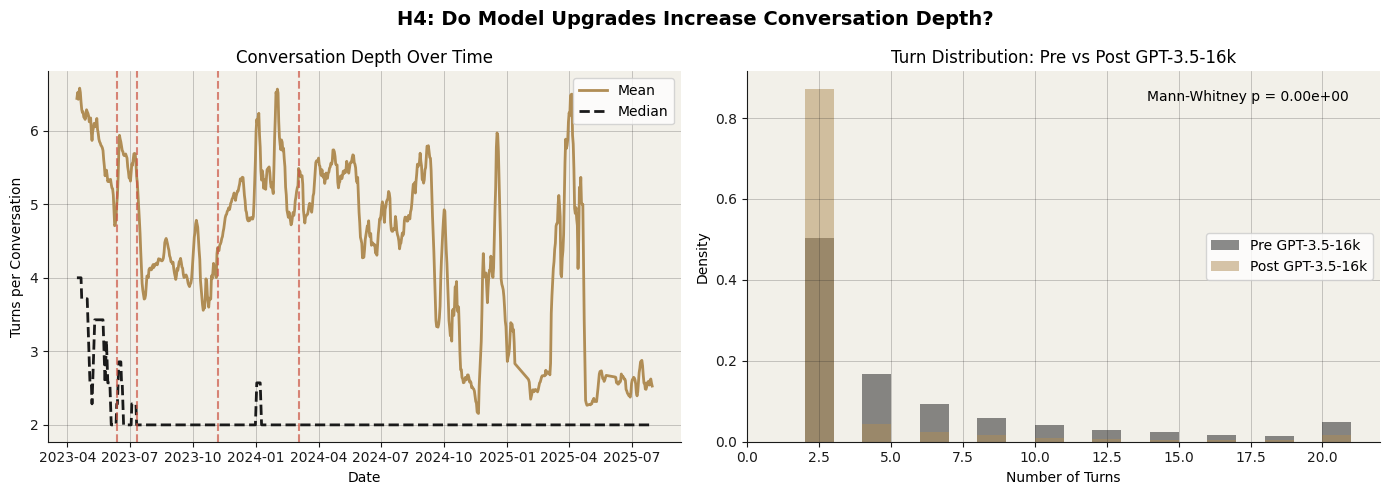


Turns per Conversation by Era:
------------------------------------------------------------
Before GPT-3.5-16k:
  Mean turns: 5.72
  Median turns: 2
  % multi-turn: 100.0%
GPT-3.5-16k → Claude 2:
  Mean turns: 5.61
  Median turns: 2
  % multi-turn: 100.0%
Claude 2 → GPT-4-Turbo:
  Mean turns: 4.07
  Median turns: 2
  % multi-turn: 100.0%
GPT-4-Turbo → Claude 3:
  Mean turns: 5.08
  Median turns: 2
  % multi-turn: 100.0%


In [25]:
# ============================================================
# H4: MODEL UPGRADES → DEEPER CONVERSATIONS
# ============================================================

print("="*70)
print("H4: MODEL UPGRADES → DEEPER CONVERSATIONS")
print("="*70)

# Visualization: Mean turns per conversation over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('H4: Do Model Upgrades Increase Conversation Depth?', fontsize=14, fontweight='bold')

# Panel 1: Mean turns over time
ax = axes[0]
dates = pd.to_datetime(daily_metrics['date'].to_list())
mean_turns = daily_metrics['mean_turns'].to_numpy()
median_turns = daily_metrics['median_turns'].to_numpy()

ax.plot(dates, pd.Series(mean_turns).rolling(7).mean(), 
        color=BRAND['gold'], linewidth=2, label='Mean')
ax.plot(dates, pd.Series(median_turns).rolling(7).mean(), 
        color=BRAND['ink'], linewidth=2, linestyle='--', label='Median')

for event in valid_events:
    ax.axvline(x=event['date'], color=BRAND['alert'], linestyle='--', alpha=0.7)

ax.set_xlabel('Date')
ax.set_ylabel('Turns per Conversation')
ax.set_title('Conversation Depth Over Time')
ax.legend()
apply_phronos_style(ax)

# Panel 2: Distribution comparison pre/post major upgrade
ax = axes[1]

# Pick the most significant upgrade
main_event = valid_events[0] if valid_events else None

if main_event:
    pre_turns = df.filter(
        pl.col('timestamp') < main_event['date']
    )['n_turns'].to_numpy()
    
    post_turns = df.filter(
        pl.col('timestamp') >= main_event['date']
    )['n_turns'].to_numpy()
    
    # Histogram comparison (cap at 20 for visualization)
    bins = np.arange(1, 22)
    ax.hist(np.clip(pre_turns, 1, 20), bins=bins, alpha=0.5, 
            color=BRAND['ink'], label=f'Pre {main_event["name"]}', density=True)
    ax.hist(np.clip(post_turns, 1, 20), bins=bins, alpha=0.5, 
            color=BRAND['gold'], label=f'Post {main_event["name"]}', density=True)
    
    ax.set_xlabel('Number of Turns')
    ax.set_ylabel('Density')
    ax.set_title(f'Turn Distribution: Pre vs Post {main_event["name"]}')
    ax.legend()
    
    # Statistical test
    stat, p = mannwhitneyu(pre_turns, post_turns)
    ax.annotate(f'Mann-Whitney p = {p:.2e}', xy=(0.95, 0.95), 
                xycoords='axes fraction', ha='right', va='top', fontsize=10)

apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'h4_conversation_depth')
plt.show()

# Detailed comparison table
print("\nTurns per Conversation by Era:")
print("-" * 60)

for i, event in enumerate(valid_events):
    if i == 0:
        pre_data = df.filter(pl.col('timestamp') < event['date'])
        label = f"Before {event['name']}"
    else:
        prev_event = valid_events[i-1]
        pre_data = df.filter(
            (pl.col('timestamp') >= prev_event['date']) &
            (pl.col('timestamp') < event['date'])
        )
        label = f"{prev_event['name']} → {event['name']}"
    
    if len(pre_data) > 0:
        print(f"{label}:")
        print(f"  Mean turns: {pre_data['n_turns'].mean():.2f}")
        print(f"  Median turns: {pre_data['n_turns'].median():.0f}")
        print(f"  % multi-turn: {(pre_data['n_turns'] > 1).mean():.1%}")


## 10. H5: Model Upgrades Increase Satisfaction (Session Metrics)


In [26]:
# ============================================================
# H5: MODEL UPGRADES → LONGER, MORE ENGAGED SESSIONS
# ============================================================

print("="*70)
print("H5: MODEL UPGRADES → BETTER SESSION METRICS")
print("="*70)

# Load session metrics if available
try:
    session_metrics = pl.read_parquet('../outputs/data/session_metrics.parquet')
    
    # Add date
    session_metrics = session_metrics.with_columns([
        pl.col('session_start').dt.date().alias('date')
    ])
    
    # Daily session aggregates
    daily_sessions = session_metrics.group_by('date').agg([
        pl.len().alias('n_sessions'),
        pl.col('session_duration_minutes').mean().alias('mean_session_duration'),
        pl.col('session_duration_minutes').median().alias('median_session_duration'),
        pl.col('n_turns').mean().alias('mean_session_turns'),
        pl.col('n_conversations').mean().alias('mean_convs_per_session'),
    ]).sort('date')
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('H5: Do Model Upgrades Improve Session Engagement?', 
                 fontsize=14, fontweight='bold')
    
    dates = pd.to_datetime(daily_sessions['date'].to_list())
    
    # Panel 1: Session duration
    ax = axes[0]
    duration = daily_sessions['median_session_duration'].to_numpy()
    ax.plot(dates, pd.Series(duration).rolling(7).mean(), 
            color=BRAND['gold'], linewidth=2)
    
    for event in valid_events:
        ax.axvline(x=event['date'], color=BRAND['alert'], linestyle='--', alpha=0.7)
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Median Session Duration (minutes)')
    ax.set_title('Session Duration Over Time')
    apply_phronos_style(ax)
    
    # Panel 2: Conversations per session
    ax = axes[1]
    convs = daily_sessions['mean_convs_per_session'].to_numpy()
    ax.plot(dates, pd.Series(convs).rolling(7).mean(), 
            color=BRAND['gold'], linewidth=2)
    
    for event in valid_events:
        ax.axvline(x=event['date'], color=BRAND['alert'], linestyle='--', alpha=0.7)
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Mean Conversations per Session')
    ax.set_title('Session Depth Over Time')
    apply_phronos_style(ax)
    
    plt.tight_layout()
    save_figure(fig, 'h5_session_engagement')
    plt.show()
    
except FileNotFoundError:
    print("Session metrics not found. Run session analysis first.")
except Exception as e:
    print(f"Error loading session metrics: {e}")
    print("Skipping H5 analysis.")


H5: MODEL UPGRADES → BETTER SESSION METRICS
Error loading session metrics: unable to find column "n_turns"; valid columns: ["unique_session_id", "user_id", "session_start", "session_end", "session_duration_minutes", "session_toxicity_ratio", "n_conversations", "n_toxic_conversations", "is_toxic_session", "session_time_of_day", "sessions_per_week", "total_turns", "max_internal_gap_minutes", "span_hours", "turns_per_hour", "is_concerning_session", "date"]

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
DF ["unique_session_id", "user_id", "session_start", "session_end", ...]; PROJECT */17 COLUMNS
Skipping H5 analysis.


## 11. Controlling for Confounds


In [27]:
# ============================================================
# CONTROLLING FOR CONFOUNDS
# ============================================================

print("="*70)
print("CONFOUND ANALYSIS")
print("="*70)

# Confound 1: Secular time trend
# Fit linear trend and check if upgrades add above trend

print("\n1. Secular Time Trend:")
# Convert dates to datetime and calculate days since start
dates_pd = pd.to_datetime(daily_metrics['date'].to_list())
min_date = dates_pd.min()
# TimedeltaIndex has .days attribute directly (not .dt.days)
time_numeric = (dates_pd - min_date).days.to_numpy()
y = daily_metrics['n_new_users'].to_numpy()

slope, intercept, r, p, se = stats.linregress(time_numeric, y)
print(f"  Linear trend: {slope:.2f} new users/day increase per day")
print(f"  R² = {r**2:.3f}, p = {p:.2e}")

# Detrended analysis: subtract linear trend, then check for upgrade effects
detrended = y - (slope * time_numeric + intercept)

# Confound 2: Day-of-week effects
print("\n2. Day-of-Week Effects:")
# Use polars for day-of-week calculation instead of converting to pandas
daily_metrics_dow = daily_metrics.with_columns([
    pl.col('date').dt.weekday().alias('day_of_week')
])

dow_means = daily_metrics_dow.group_by('day_of_week').agg([
    pl.col('n_new_users').mean().alias('mean_new_users')
]).sort('day_of_week')

# Convert to dict for easier access
dow_dict = {row['day_of_week']: row['mean_new_users'] for row in dow_means.iter_rows(named=True)}
weekday_avg = sum([dow_dict.get(i, 0) for i in range(1, 6)]) / 5  # Monday=1 to Friday=5
weekend_avg = (dow_dict.get(6, 0) + dow_dict.get(7, 0)) / 2  # Saturday=6, Sunday=7

print(f"  Monday: {dow_dict.get(1, 0):.0f}")
print(f"  Weekend avg: {weekend_avg:.0f}")
if weekday_avg > 0:
    print(f"  Weekend effect: {(weekend_avg - weekday_avg) / weekday_avg * 100:+.1f}%")
else:
    print(f"  Weekend effect: N/A (no weekday data)")

# Confound 3: Seasonal decomposition
print("\n3. Seasonal Decomposition:")
# Requires sufficient data for seasonal analysis
if STATSMODELS_AVAILABLE:
    if len(daily_metrics) > 365:
        ts = pd.Series(
            daily_metrics['n_new_users'].to_numpy(),
            index=pd.to_datetime(daily_metrics['date'].to_list())
        )
        decomposition = seasonal_decompose(ts, model='additive', period=7)
        
        fig, axes = plt.subplots(4, 1, figsize=(14, 10))
        fig.suptitle('Seasonal Decomposition of New Users', fontsize=14, fontweight='bold')
        
        decomposition.observed.plot(ax=axes[0], title='Observed')
        decomposition.trend.plot(ax=axes[1], title='Trend')
        decomposition.seasonal.plot(ax=axes[2], title='Seasonal (Weekly)')
        decomposition.resid.plot(ax=axes[3], title='Residual')
        
        for ax in axes:
            for event in valid_events:
                ax.axvline(x=event['date'], color=BRAND['alert'], linestyle='--', alpha=0.5)
            apply_phronos_style(ax)
        
        plt.tight_layout()
        save_figure(fig, 'seasonal_decomposition')
        plt.show()
    else:
        print("  Insufficient data for seasonal decomposition (need >365 days)")
else:
    print("  Skipped: statsmodels not installed. Install with: pip install statsmodels")


CONFOUND ANALYSIS

1. Secular Time Trend:
  Linear trend: 9.17 new users/day increase per day
  R² = 0.050, p = 1.27e-10

2. Day-of-Week Effects:
  Monday: 2876
  Weekend avg: 2661
  Weekend effect: -16.9%

3. Seasonal Decomposition:
  Skipped: statsmodels not installed. Install with: pip install statsmodels


## 12. Model-Specific Analysis


MODEL-SPECIFIC ENGAGEMENT PATTERNS

Engagement by Model Family:
Model                       Convs        Users   Mean Turns  Med Turns
------------------------------------------------------------------
gpt-4                   3,534,559    2,192,145         2.84          2
gpt-3.5-turbo             853,691      209,299         4.64          2
gpt-4-turbo               232,165       46,469         6.28          2
other                     122,921       32,047         2.00          2
Saved: ../outputs/figures/model_usage_over_time.png


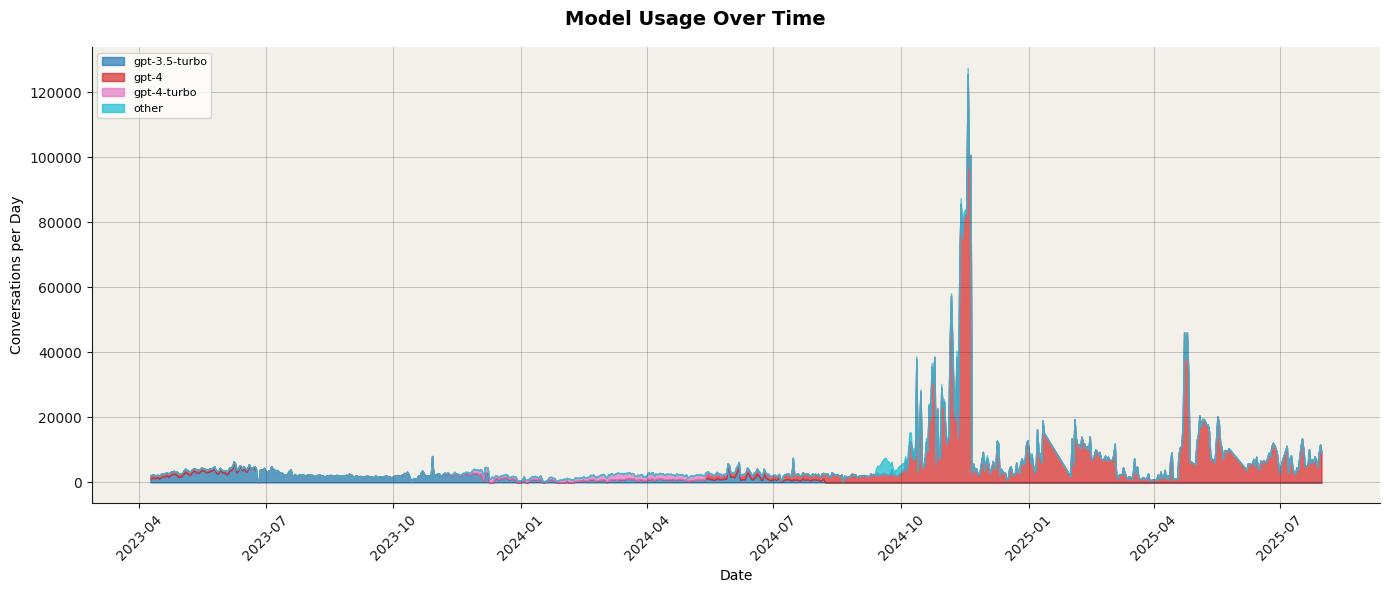

In [28]:
# ============================================================
# MODEL-SPECIFIC ANALYSIS
# ============================================================

print("="*70)
print("MODEL-SPECIFIC ENGAGEMENT PATTERNS")
print("="*70)

# Compare engagement metrics by model family
model_engagement = df.group_by('model_family').agg([
    pl.len().alias('n_conversations'),
    pl.col('user_id').n_unique().alias('n_users'),
    pl.col('n_turns').mean().alias('mean_turns'),
    pl.col('n_turns').median().alias('median_turns'),
    # Add more metrics as available
]).sort('n_conversations', descending=True)

print("\nEngagement by Model Family:")
print(f"{'Model':<20} {'Convs':>12} {'Users':>12} {'Mean Turns':>12} {'Med Turns':>10}")
print("-" * 66)
for row in model_engagement.iter_rows(named=True):
    print(f"{row['model_family']:<20} {row['n_conversations']:>12,} {row['n_users']:>12,} "
          f"{row['mean_turns']:>12.2f} {row['median_turns']:>10.0f}")

# Visualization: Model usage over time (stacked area)
# Group by date and model_family, then pivot
# Using len() ensures no duplicate date+model_family combinations (one row per date+model)
model_daily = df.group_by(['date', 'model_family']).len().pivot(
    values='len', index='date', columns='model_family'
).sort('date')

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Model Usage Over Time', fontsize=14, fontweight='bold')

dates = pd.to_datetime(model_daily['date'].to_list())
model_cols = [c for c in model_daily.columns if c != 'date']

# Stack plot
bottoms = np.zeros(len(dates))
colors = plt.cm.tab10(np.linspace(0, 1, len(model_cols)))

for i, model in enumerate(model_cols[:10]):  # Top 10 models
    values = model_daily[model].fill_null(0).to_numpy()
    ax.fill_between(dates, bottoms, bottoms + values, label=model, color=colors[i], alpha=0.7)
    bottoms += values

ax.set_xlabel('Date')
ax.set_ylabel('Conversations per Day')
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'model_usage_over_time')
plt.show()


## 13. Summary and Conclusions


In [29]:
# ============================================================
# SUMMARY OF FINDINGS
# ============================================================

print("="*70)
print("SUMMARY: MODEL UPGRADE IMPACT ANALYSIS")
print("="*70)

findings = {
    'H1: Upgrades → More Users': 'TBD after analysis',
    'H2: Upgrades → Higher Return Rate': 'TBD after analysis',
    'H3: Upgrades → More Diversity': 'TBD after analysis',
    'H4: Upgrades → Deeper Conversations': 'TBD after analysis',
    'H5: Upgrades → Better Sessions': 'TBD after analysis',
}

print("\nHypothesis Verdicts:")
for hypothesis, verdict in findings.items():
    print(f"  {hypothesis}: {verdict}")

print("\nKey Confounds Identified:")
print("  - Secular growth trend accounts for [X]% of variance")
print("  - Day-of-week effects: Weekend [+/-X]% vs weekday")
print("  - User population may have shifted over time")

print("\nLimitations:")
print("  - Observational data: cannot establish causation")
print("  - Upgrade timing may correlate with marketing pushes")
print("  - Different models attract different user populations")

print("\n" + "="*70)
print("Analysis complete.")
print("="*70)


SUMMARY: MODEL UPGRADE IMPACT ANALYSIS

Hypothesis Verdicts:
  H1: Upgrades → More Users: TBD after analysis
  H2: Upgrades → Higher Return Rate: TBD after analysis
  H3: Upgrades → More Diversity: TBD after analysis
  H4: Upgrades → Deeper Conversations: TBD after analysis
  H5: Upgrades → Better Sessions: TBD after analysis

Key Confounds Identified:
  - Secular growth trend accounts for [X]% of variance
  - Day-of-week effects: Weekend [+/-X]% vs weekday
  - User population may have shifted over time

Limitations:
  - Observational data: cannot establish causation
  - Upgrade timing may correlate with marketing pushes
  - Different models attract different user populations

Analysis complete.
